[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lshofsl/Advanced-topics-in-PoD-project-/blob/main/EBM_NCA.ipynb)

In [1]:
# Baseline NCA adapted
# @misc{guichard2025engramncaneuralcellularautomaton,
     # title={EngramNCA: a Neural Cellular Automaton Model of Memory Transfer},
     # author={Etienne Guichard and Felix Reimers and Mia Kvalsund and Mikkel Lepperød and Stefano Nichele},
     # year={2025},
     # eprint={2504.11855},
     # archivePrefix={arXiv},
     # primaryClass={cs.NE},
     # url={https://arxiv.org/abs/2504.11855},
#}



import os
import sys

!rm -rf Advanced-topics-in-PoD-project-
!git clone https://github.com/lshofsl/Advanced-topics-in-PoD-project-.git

repo_path = os.path.abspath("Advanced-topics-in-PoD-project-")
if repo_path not in sys.path:
    sys.path.insert(0, repo_path)

if os.path.exists(repo_path):
    print("Success! Files now found:", os.listdir(repo_path))

Cloning into 'Advanced-topics-in-PoD-project-'...
remote: Enumerating objects: 616, done.
remote: Counting objects: 100% (134/134), done.
remote: Compressing objects: 100% (134/134), done.
remote: Total 616 (delta 80), reused 0 (delta 0), pack-reused 482 (from 2)
Receiving objects: 100% (616/616), 27.20 MiB | 1.20 MiB/s, done.
Resolving deltas: 100% (342/342), done.
Success! Files now found: ['Images', 'NCA.py', 'NCA_baseline.py', 'EBM_NCA.ipynb', '.git', 'pathway.py', 'README.md', 'utils.py', 'ER_NCA.ipynb', 'EBM_NCA_baseline.ipynb']


In [2]:
#@title Imports { vertical-output: true}
import random
import numpy as np
import matplotlib.pyplot as plt
import torch

os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

from NCA import *
import utils as utils
from IPython.display import Image, HTML, clear_output
import torch.nn.functional as F
import logging
from IPython.display import display, HTML, Video
from PIL import Image
import cv2
import pandas as pd
from base64 import b64encode
from sklearn.decomposition import PCA
logger = logging.getLogger()
old_level = logger.level
logger.setLevel(100)


Using device: cuda


In [3]:
#@title Setup { vertical-output: true}
HEIGHT = 35 #@param {type:"integer"}
WIDTH = 35 #@param {type:"integer"}
CHANNELS = 16 # @param {type:"integer"}<--- NCA feature channels
BATCH_SIZE = 12 #@param {type:"integer"}
PADDING = 5 #@param {type:"integer"}
POOL_SIZE = 1536 #@param {type:"integer"}<--- NCA training pool size, lower values train faster but are less stable
TRAINING_ITERS = 3000  #@param {type:"integer"}<-- Number of trainign iterations
HIDDEN_SIZE = 64 #@param {type:"integer"}<--- NCA hidden size


style = """
<style>
.output_wrapper, .output {
    display: flex;
    flex-direction: row-reverse; /* Align content to the right */
}
</style>
"""


In [4]:
#@title Load Primitives { vertical-output: true}

LIZARD = "Images/square.png"
path = LIZARD
image, image_to_display = utils.get_image(os.path.join(repo_path, path), HEIGHT, WIDTH, padding=PADDING)

HEIGHT = HEIGHT + 2*PADDING
WIDTH = WIDTH + 2*PADDING


In [5]:
class SamplePool:
  def __init__(self, *, _parent=None, _parent_idx=None, **slots):
    self._parent = _parent
    self._parent_idx = _parent_idx
    self._slot_names = slots.keys()
    self._size = None
    for k, v in slots.items():
      if self._size is None:
        self._size = len(v)
      assert self._size == len(v)
      setattr(self, k, np.asarray(v))

  def sample(self, n):
    idx = np.random.choice(self._size, n, False)
    batch = {k: getattr(self, k)[idx] for k in self._slot_names}
    batch = SamplePool(**batch, _parent=self, _parent_idx=idx)
    return batch

  def commit(self):
    for k in self._slot_names:
      getattr(self._parent, k)[self._parent_idx] = getattr(self, k)

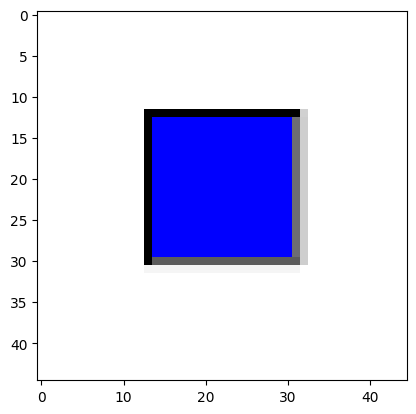

In [6]:
#@title Display Primitives { vertical-output: true}
def make_seed(size, channels=16):
    x = np.zeros([channels, size, size], dtype=np.float32)
    x[3:, size // 2, size // 2] = 1.0
    return x

seed = make_seed(HEIGHT, CHANNELS)

pool_inputs = np.repeat(seed[None, ...], POOL_SIZE, axis=0)
pool = SamplePool(x=pool_inputs)


plt.imshow(image_to_display)
plt.show()

In [7]:
#@title Get Batch Image Partitions { vertical-output: true}
batch = pool.sample(BATCH_SIZE)

In [8]:
#@title Load Filters for Loss Function { vertical-output: true}

sobel_x = torch.tensor([[-1.0, 0.0, 1.0], [-2.0, 0.0, 2.0], [-1.0, 0.0, 1.0]], dtype=torch.float32, device=DEVICE)
lap = torch.tensor([[1.0, 2.0, 1.0], [2.0, -12, 2.0], [1.0, 2.0, 1.0]], dtype=torch.float32, device=DEVICE)
filters = torch.stack([sobel_x, sobel_x.T, lap])
folder = "weights"

In [9]:
#@title Create Path for Saving Models { vertical-output: true}
path = "Trained_models/" + folder
if not os.path.exists(path):
    os.makedirs(path)
    print(f"Path: {path} created")
else:
    print(f"Path: {path} already exists, all OK!")


Path: Trained_models/weights already exists, all OK!


In [10]:
#@title Initialise NCA { vertical-output: true}
base = image.tile(BATCH_SIZE, 1, 1, 1).to(DEVICE)
loss_log = []
nca = EnergyOnlyNCA(chn=16, v_dim=4).to(DEVICE)
nca.set_target_anchor(base)

optim = torch.optim.AdamW(nca.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optim, step_size=2000, gamma=0.3)
name = folder + "/" +type(nca).__name__

In [25]:
# 1. Confirm K_hebb only touches the visible block
assert nca.K_hebb[nca.v_dim:, :, :, :].abs().sum() == 0
assert nca.K_hebb[:, nca.v_dim:, :, :].abs().sum() == 0

# 2. Confirm K_hebb now actually influences the dynamics (this was the whole bug)
K_before = nca._symmetric_kernel().clone()
nca.K_hebb.zero_()
K_after = nca._symmetric_kernel()
assert not torch.allclose(K_before, K_after)   # should now differ — proves K_hebb has an effect

# 3. Gradient still correct after these changes
s = torch.randn(1, 16, 8, 8, device=DEVICE, requires_grad=True)
E = nca.energy(s)
grad_autograd = torch.autograd.grad(E.sum(), s)[0]
grad_manual = nca.energy_gradient(s, clamp=False)
print("max abs diff:", (grad_autograd - grad_manual).abs().max().item())

AssertionError: 

In [12]:
def create_circular_mask(HEIGHT, WIDTH, center_x, center_y, radius, device="cuda:0"):
    height, width = HEIGHT, WIDTH
    y_grid, x_grid = torch.meshgrid(
        torch.arange(height, device=device),
        torch.arange(width, device=device),
        indexing='ij'
    )
    distance_squared = (x_grid - center_x) ** 2 + (y_grid - center_y) ** 2
    return distance_squared <= (radius ** 2)


Batch


Per-sample pixel loss: [0.07738051 0.07713116 0.07555421 0.07336653 0.06515055 0.06093752
 0.0561118  0.04739402 0.0408881  0.03656024 0.03369842 0.02461481]
Per-sample edge loss: [0.31818855 0.31585786 0.31581554 0.3166379  0.31758955 0.30873954
 0.30216515 0.28927782 0.35025027 0.30141157 0.2878244  0.29323572]


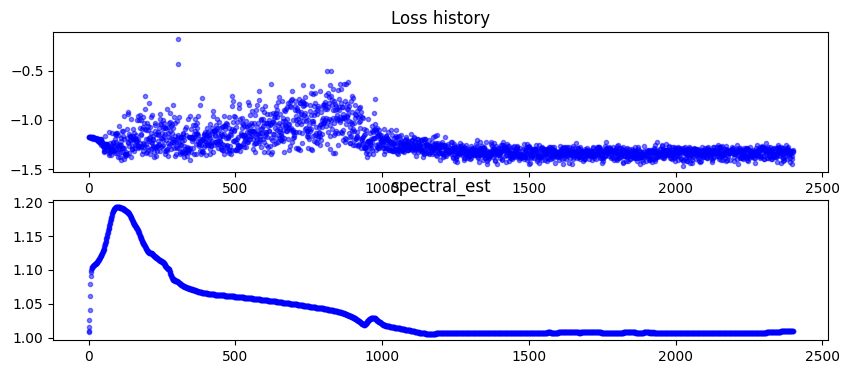

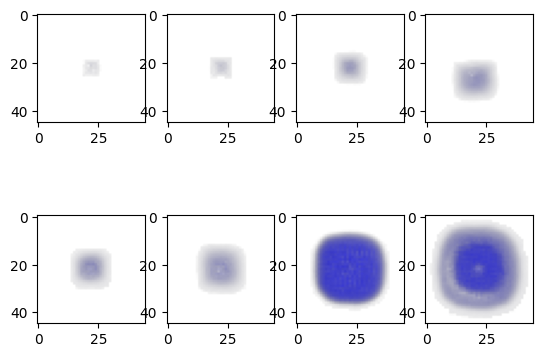

Trained_models/weights/EnergyOnlyNCA.pth


KeyboardInterrupt: 

In [13]:
#@title Training { vertical-output: true}
DAMAGE_N = 0

lambda_mono = 0.1
lambda_drift = 0.5
lambda_stability = 0.01
K = 20


eta_log = []
k_norm_log = []
energy_loss = []
gamma_log = []
gamma_boundary = []
gamma_sobel = []
spectral_est_log =[]

checkpoint_iters = [0,200,400, 900, 1500, 2000, 2500, 3000]

for i in range(TRAINING_ITERS + 1):
    # 1. Pool Sampling & Manipulation
    with torch.no_grad():
      batch = pool.sample(BATCH_SIZE)
      x0_np = batch.x.copy()  # Shape: (BATCH_SIZE, C, H, W)

      x0_tensor = torch.from_numpy(x0_np).to(DEVICE)
      pre_pixel_loss = (x0_tensor[:, :4, :, :] - base).pow(2).mean(dim=[1, 2, 3])

      # Sort indices (descending: highest loss first)
      loss_rank = pre_pixel_loss.cpu().numpy().argsort()[::-1]

      # Re-order x0_np AND align pool slot indices so write-back stays consistent
      x0_np = x0_np[loss_rank]

      # B. Replace highest-loss sample (index 0) with fresh seed
      seed_np = seed.detach().cpu().numpy() if isinstance(seed, torch.Tensor) else seed.copy()
      if seed_np.ndim == 4:
          seed_np = seed_np[0]

      x0_np[0] = seed_np

      # C. Apply damage to the BEST performing samples (lowest loss at the end of sorted array)
      if DAMAGE_N > 0:
          for idx in range(1, DAMAGE_N + 1):
              cx = random.randint(int(WIDTH * 0.2), int(WIDTH * 0.8))
              cy = random.randint(int(HEIGHT * 0.2), int(HEIGHT * 0.8))
              r = random.randint(4, 10)

              mask_np = create_circular_mask(HEIGHT, WIDTH, cx, cy, radius=r).cpu().numpy().astype(np.float32)

                # Ensure mask matches (1, H, W) or (C, H, W) explicitly
              if mask_np.ndim == 2:
                  mask_np = mask_np[None, ...]  # Shape: (1, H, W)

              damage = 1.0 - mask_np
              x0_np[-idx] *= damage

        # Send fully prepared initial state to GPU
      x = torch.from_numpy(x0_np).to(DEVICE)

    # 2. Rollout loop
    T = random.randrange(64, 94)
    energies = []
    for t in range(T):
        E_t = nca.energy(x)
        energies.append(E_t)
        x = nca(x)
    energies.append(nca.energy(x))

    pixel_loss = (x[:, :4, :, :] - base).pow(2).mean(dim=[1, 2, 3])
    edge_loss = (perchannel_conv(base, filters) - perchannel_conv(x[:, :4, :, :], filters)).pow(2).mean(dim=[1, 2, 3])

    per_sample_loss = pixel_loss +  0.4*edge_loss
    loss_recon = per_sample_loss.mean()

    energies_t = torch.stack(energies[:-1])
    energies_t1 = torch.stack(energies[1:])
    loss_mono = torch.relu(energies_t1 - energies_t).mean()

    x_at_T = x.clone()
    loss_drift = 0.0
    for t in range(K):
        x = nca(x)


        # Calculate pixel and edge drift at step T + t
        drift_pixel = (x[:, :4, :, :] - base).pow(2).mean(dim=[1, 2, 3])
        drift_edge = (perchannel_conv(base, filters) - perchannel_conv(x[:, :4, :, :], filters)).pow(2).mean(dim=[1, 2, 3])

        # Combine per-sample drift and accumulate
        step_drift = drift_pixel + 0.4*drift_edge
        loss_drift += step_drift.mean()

    # Normalize loss_drift over the K additional steps
    loss_drift = loss_drift / K

    spectral_est = nca.estimate_spectral_radius(num_iters=5)
    safety_margin = 0.98
    stability_penalty = torch.relu(spectral_est - safety_margin) ** 2   # only penalize once it approaches/exceeds the margin

    spectral_est_log.append(spectral_est.item())

    loss = (loss_recon
            + lambda_mono * loss_mono
            + lambda_drift * loss_drift
            + lambda_stability * stability_penalty)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(nca.parameters(), max_norm=1.0)
    optim.step()
    optim.zero_grad()

    eta_log.append(nca.log_eta.detach().item())
    gamma_log.append(nca.log_gamma.detach().item())
    gamma_boundary.append(nca.log_gamma_boundary.detach().item())
    gamma_sobel.append(nca.log_gamma_sobel.detach().item())
    energy_loss.append(loss.item())
    k_norm_log.append(nca.K_raw.norm().item())
    loss_log.append(loss.log().item())

    with torch.no_grad():
      batch.x[:] = x_at_T.detach().cpu().numpy()
      batch.commit()

    scheduler.step()



    if i % 100 == 0:
      print(f"Training itter {i}, loss = {loss.item()}")
      clear_output()
      fig, axes = plt.subplots(2, 1, figsize=(10, 4))
      axes[0].set_title('Loss history')
      axes[0].plot(loss_log, '.', alpha=0.5, color="b")
      axes[1].set_title('spectral_est')
      axes[1].plot(spectral_est_log, '.', alpha=0.5, color="b")
      print("Batch")
      utils.show_batch(x_at_T[2:14])
      display(HTML(style))
      print("Per-sample pixel loss:", pixel_loss.detach().cpu().numpy())
      print("Per-sample edge loss:", edge_loss.detach().cpu().numpy())
      plt.show(block=False)
      plt.pause(0.01)

      torch.save(nca.state_dict(), "Trained_models/" + name + ".pth")
      print("Trained_models/" + name + ".pth")

      if i in checkpoint_iters:
        torch.save(nca.state_dict(), f"Trained_models/{name}_ckpt_{i}.pth")


In [24]:
nca.estimate_spectral_radius(num_iters=5, spatial_size=40)

tensor(1.0007, device='cuda:0', grad_fn=<DivBackward0>)

In [14]:
@torch.no_grad()
def dominant_growth_rate(nca, s_probe, n_iter=20, eps=1e-3):
    """
    Estimates |dominant eigenvalue| of the linearized update operator
    (I - eta * Hessian(E)) around a given state s_probe, via power
    iteration using finite-difference Jacobian-vector products.
    """
    eta = torch.nn.functional.softplus(nca.log_eta).item()
    v = torch.randn_like(s_probe)
    v = v / v.norm()

    grad_0 = nca.energy_gradient(s_probe)
    for _ in range(n_iter):
        grad_plus = nca.energy_gradient(s_probe + eps * v)
        Jv = (grad_plus - grad_0) / eps        # ≈ Hessian(E) @ v
        Av = v - eta * Jv                       # linearized update operator @ v
        norm_Av = Av.norm()
        v = Av / (norm_Av + 1e-8)

    return norm_Av.item()

In [16]:
growth_rates = []

for ckpt_iter in [200,400,900,1500,2000]:
    nca_ckpt = EnergyOnlyNCA(chn=16, v_dim=4).to(DEVICE)
    nca_ckpt.load_state_dict(torch.load(f"Trained_models/{name}_ckpt_{ckpt_iter}.pth"))
    nca_ckpt.eval()

    x_probe = torch.from_numpy(seed[None, ...]).to(DEVICE) if isinstance(seed, np.ndarray) else seed.clone().to(DEVICE)
    rate = dominant_growth_rate(nca_ckpt, x_probe)
    growth_rates.append(rate)
    print(f"iter {ckpt_iter}: dominant growth rate = {rate:.4f}")

iter 200: dominant growth rate = 1.0049
iter 400: dominant growth rate = 1.0039
iter 900: dominant growth rate = 1.0025
iter 1500: dominant growth rate = 1.0024
iter 2000: dominant growth rate = 1.0024


ValueError: x and y must have same first dimension, but have shapes (8,) and (5,)

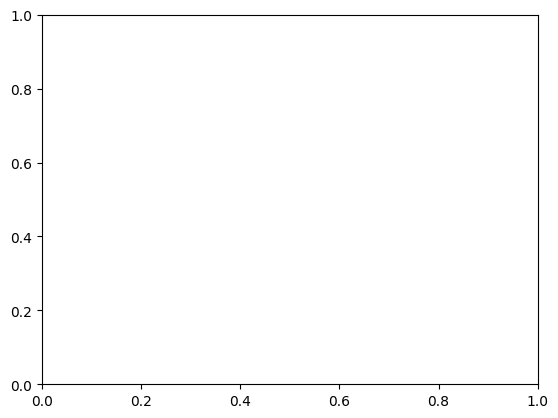

In [17]:
fig, ax1 = plt.subplots()
ax1.plot(checkpoint_iters, growth_rates, 'o-', color='tab:red', label='Dominant growth rate')
ax1.axhline(y=1.0, color='gray', linestyle='--', label='Stability threshold')
ax1.set_xlabel('Training iteration')
ax1.set_ylabel('|dominant eigenvalue|', color='tab:red')

ax2 = ax1.twinx()
ax2.plot(range(len(k_norm_log)), k_norm_log, color='tab:blue', alpha=0.5, label='||K_raw||')
ax2.set_ylabel('||K_raw||', color='tab:blue')

plt.title('Stability margin vs. coupling norm over training')
plt.show()

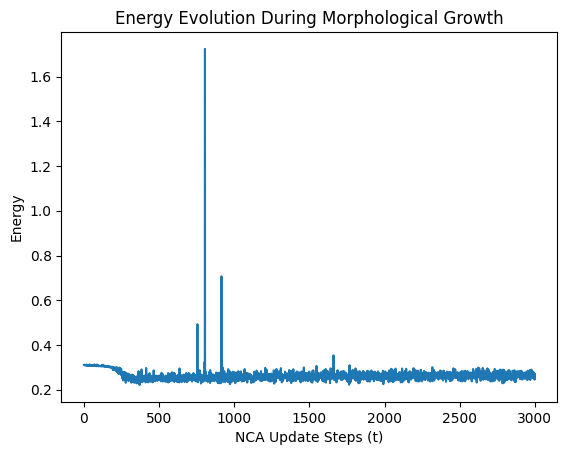

In [ ]:
plt.plot(energy_loss)
plt.xlabel("NCA Update Steps (t)")
plt.ylabel("Energy")
plt.title("Energy Evolution During Morphological Growth")
plt.show()

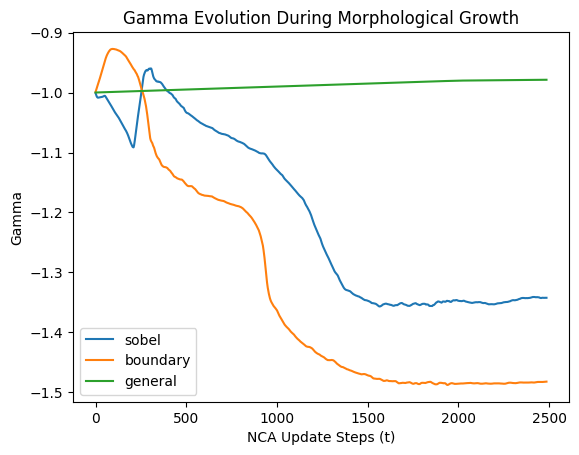

In [22]:
plt.plot(gamma_sobel, label = "sobel")
plt.plot(gamma_boundary, label = "boundary")
plt.plot(gamma_log, label="general")
plt.xlabel("NCA Update Steps (t)")
plt.ylabel("Gamma")
plt.title("Gamma Evolution During Morphological Growth")
plt.legend()
plt.show()


In [18]:
del nca
del optim
torch.cuda.empty_cache()

In [19]:
nca = EnergyOnlyNCA(CHANNELS,4)
nca.load_state_dict(torch.load("Trained_models/weights/EnergyOnlyNCA.pth"))
nca.to(DEVICE).eval()

EnergyOnlyNCA()

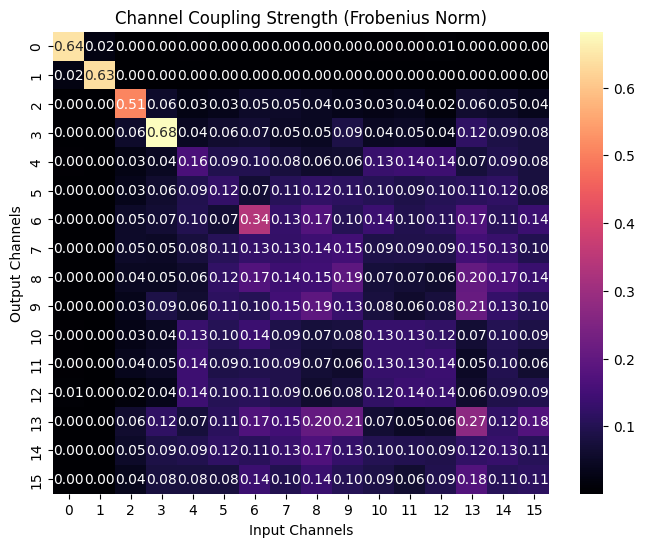

In [20]:
import seaborn as sns
@torch.no_grad()
def plot_channel_interaction(model):
    # Extract symmetric kernel: shape (16, 16, 3, 3)
    K = model._symmetric_kernel().detach().cpu()

    # Compute magnitude per channel pair -> shape (16, 16)
    K_norm = torch.norm(K, dim=(-2, -1)).numpy()

    plt.figure(figsize=(8, 6))
    sns.heatmap(K_norm, annot=True, fmt=".2f", cmap="magma", cbar=True)
    plt.title("Channel Coupling Strength (Frobenius Norm)")
    plt.xlabel("Input Channels")
    plt.ylabel("Output Channels")
    plt.show()


plot_channel_interaction(nca)

In [ ]:
def find_convergence_step(mse_sequence, patience=10, delta_tol=1e-4, target_mse=0.005):
    patience_counter = 0
    prev_mse = float('inf')

    for i, current_mse in enumerate(mse_sequence):
        delta_mse = abs(prev_mse - current_mse)
        if current_mse < target_mse and delta_mse < delta_tol:
            patience_counter += 1
        else:
            patience_counter = 0

        if patience_counter >= patience:
            return i - patience + 1

        prev_mse = current_mse

    return None

/tmp/ipykernel_887/4036165174.py:94: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax_mono.set_yscale('log')


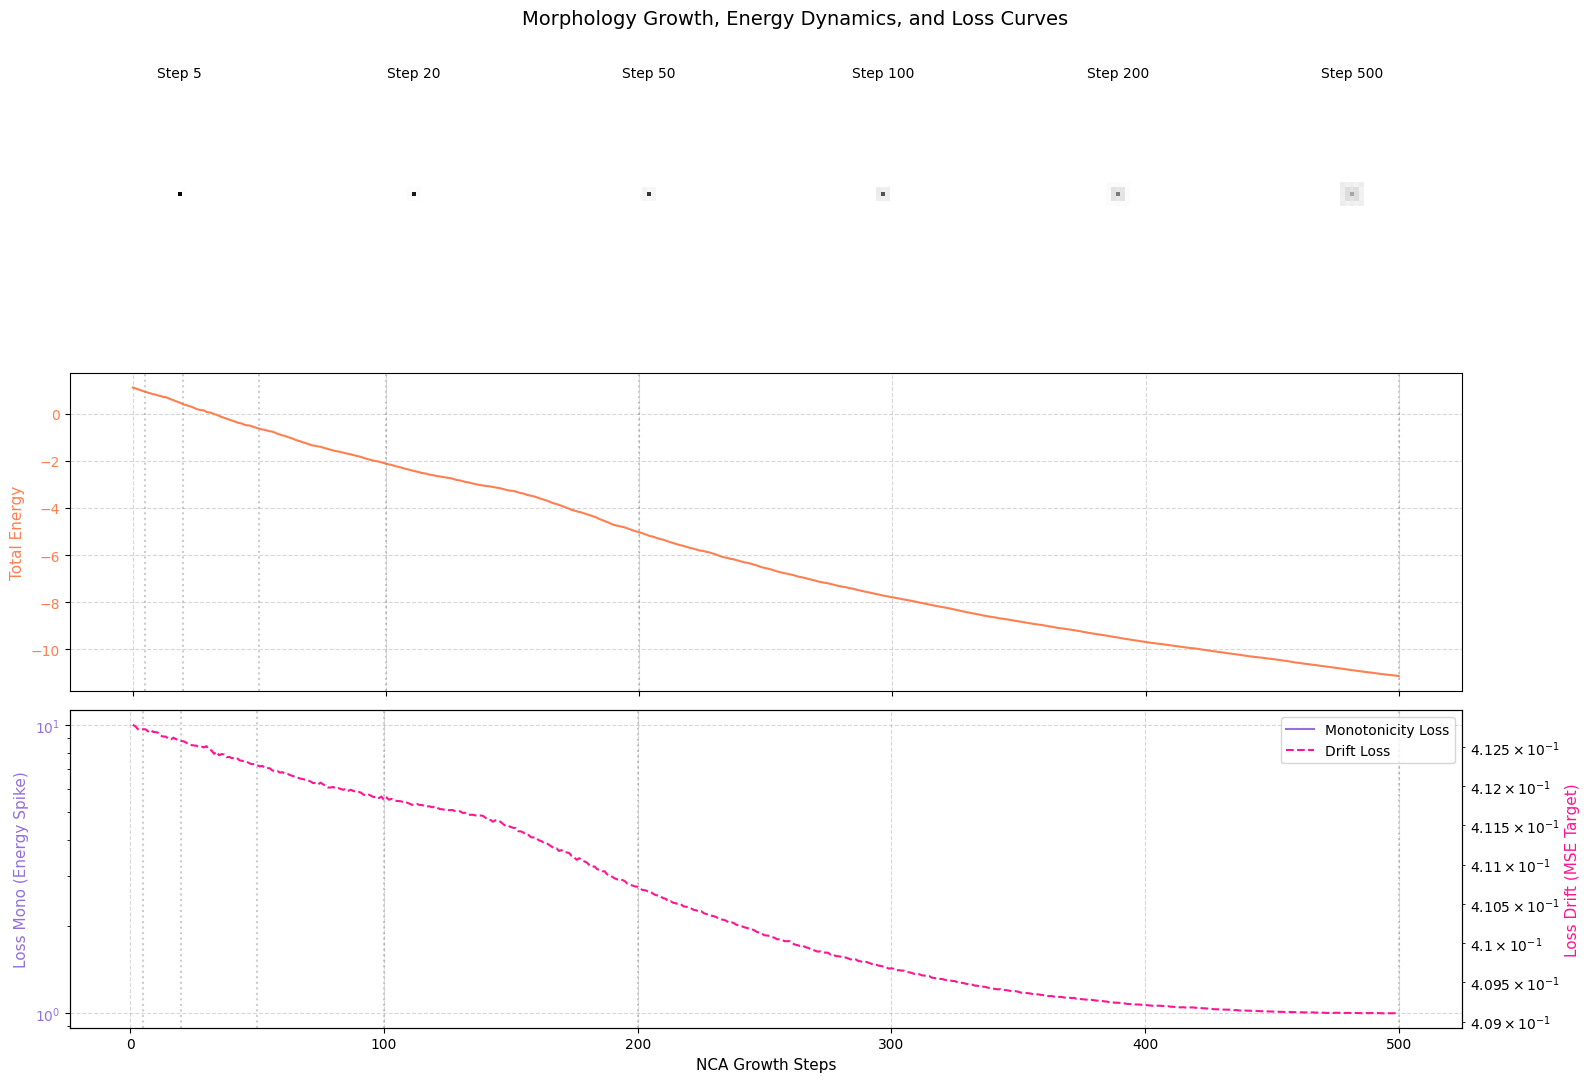

Did not converge within the observed window


In [ ]:
## Growing the morphology
def visualize_growth(nca, seed, base, steps_to_show=[5, 20, 50, 100, 200, 500], device='cuda:0'):
    x = torch.from_numpy(seed[None, ...]).to(device) if isinstance(seed, np.ndarray) else seed.clone().to(device)
    base_target = base.to(device)

    max_steps = max(steps_to_show)

    # Tracking metrics across steps
    total_energy_history = []
    loss_mono_history = []
    loss_drift_history = []
    captured_frames = []
    mse_log = []

    live_mask = (base_target[:, 3:4] > 0.1).float()

    with torch.no_grad():
      E0 = nca.energy(x)
      total_energy_history.append(E0.sum().item() if torch.is_tensor(E0) else float(E0))
      for step in range(1, max_steps +1 ):
          x = nca(x)

          # MSE loss

          diff = (x[:, :4] - base) * live_mask
          current_mse = (diff.pow(2).sum() / (live_mask.sum() * 4 + 1e-8)).item()
          mse_log.append(current_mse)

          # 1. Total System Energy
          E = nca.energy(x)
          energy_val = E.sum().item() if torch.is_tensor(E) else float(E)
          total_energy_history.append(energy_val)

          # 2. Monotonicity Loss: ReLU(E_{t} - E_{t-1})
          if len(total_energy_history) > 1:
              dE = total_energy_history[-1] - total_energy_history[-2]
              mono_loss = max(0.0, dE)  # Equivalent to torch.relu for scalars
          else:
              mono_loss = 0.0
          loss_mono_history.append(mono_loss)

          # 3. Drift Loss: MSE against target base without mutating main state x
          # Simulates forward rollouts from current state to evaluate drift
          x_rollout = x.clone()
          drift_accum = 0.0
          for _ in range(20):
              x_rollout = nca(x_rollout)
              diff = (base_target[:, :4] - x_rollout[:, :4])
              sq = diff.pow(2) * live_mask
              drift_accum += (sq.sum() / (live_mask.sum() * 4 + 1e-8)).item()

          loss_drift_history.append(drift_accum / 20.0)

          # 4. Capture snapshots at milestone steps
          if step in steps_to_show:
              img = x[0, :4].permute(1, 2, 0).cpu().numpy()
              img = np.clip(img, 0, 1)
              captured_frames.append((step, img))

    # --- Plotting Grid Setup: 3 Rows ---
    fig = plt.figure(figsize=(16, 11))
    fig.suptitle("Morphology Growth, Energy Dynamics, and Loss Curves", fontsize=14, y=0.98)

    steps_range = np.arange(0, max_steps + 1)
    n_snapshots = len(steps_to_show)

    # --- 1. Top Row: Morphological Snapshots ---
    for i, (step, img) in enumerate(captured_frames):
        ax = fig.add_subplot(3, n_snapshots, i + 1)
        ax.imshow(img)
        ax.set_title(f"Step {step}", fontsize=10)
        ax.axis("off")

    # --- 2. Middle Row: Continuous System Energy ---
    ax_energy = fig.add_subplot(3, 1, 2)
    ax_energy.plot(steps_range, total_energy_history, color='coral', linewidth=1.5, label='Total Energy')
    ax_energy.set_ylabel("Total Energy", color='coral', fontsize=11)
    ax_energy.tick_params(axis = 'y', labelcolor = 'coral')
    ax_energy.grid(True, linestyle='--', alpha=0.5)
    ax_energy.set_xticklabels([])  # Hide x-axis ticks for middle plot

    for s in steps_to_show:
        ax_energy.axvline(x=s, color='gray', linestyle=':', alpha=0.4)

    # --- 3. Bottom Row: Separate Subplot for Loss Mono & Loss Drift ---
    ax_mono = fig.add_subplot(3, 1, 3)
    ax_drift = ax_mono.twinx()  # Dual Y-axis for scale separation

    # Loss Mono Plot (Left Y-Axis)
    steps_loss = steps_range[1:]
    line1 = ax_mono.plot(steps_loss, loss_mono_history, color='mediumpurple', linewidth=1.5, label='Monotonicity Loss')
    ax_mono.set_ylabel("Loss Mono (Energy Spike)", color='mediumpurple', fontsize=11)
    ax_mono.tick_params(axis='y', labelcolor='mediumpurple')
    ax_mono.set_yscale('log')
    ax_mono.set_xlabel("NCA Growth Steps", fontsize=11)
    ax_mono.grid(True, linestyle='--', alpha=0.5)

    # Loss Drift Plot (Right Y-Axis)
    line2 = ax_drift.plot(steps_loss, loss_drift_history, color='deeppink', linewidth=1.5, linestyle='--', label='Drift Loss')
    ax_drift.set_ylabel("Loss Drift (MSE Target)", color='deeppink', fontsize=11)
    ax_drift.tick_params(axis='y', labelcolor='deeppink')
    ax_drift.set_yscale('log')

    # Add milestone step markers to bottom plot
    for s in steps_to_show:
        ax_mono.axvline(x=s, color='gray', linestyle=':', alpha=0.4)

    # Combined Legend for Bottom Panel
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax_mono.legend(lines, labels, loc='upper right')

    plt.tight_layout()
    plt.show()

    growth_time = find_convergence_step(mse_log)
    if growth_time is None:
        print("Did not converge within the observed window")
    else:
        print(f"Time to grow: {growth_time} steps")

visualize_growth(nca, seed, base)


In [ ]:


def measure_growth_recovery_trials(nca, seed, base_target, n_trials=10, steps=300,
                                     patience=10, delta_tol=1e-4, target_mse=0.005, device=DEVICE):
    live_mask = (base_target[:, 3:4] > 0.1).float()
    recovery_times = []
    n_recovered = 0

    for trial in range(n_trials):
        x = torch.from_numpy(seed[None, ...]).to(device) if isinstance(seed, np.ndarray) else seed.clone().to(device)
        mse_log = []   # fresh log per trial — this was the critical fix

        with torch.no_grad():
            for t in range(1, steps + 1):
                x = nca(x)
                diff = (x[:, :4] - base_target) * live_mask
                current_mse = (diff.pow(2).sum() / (live_mask.sum() * 4 + 1e-8)).item()
                mse_log.append(current_mse)

        recovery_step = find_convergence_step(mse_log, patience=patience, delta_tol=delta_tol, target_mse=target_mse)
        if recovery_step is not None:
            recovery_times.append(recovery_step)
            n_recovered += 1

    if len(recovery_times) > 0:
        mean_time = float(np.mean(recovery_times))
        std_time = float(np.std(recovery_times))
    else:
        mean_time = float('nan')
        std_time = float('nan')

    print(f"Recovered {n_recovered}/{n_trials} trials — mean: {mean_time:.2f}, std: {std_time:.2f}")
    return mean_time, std_time, n_recovered


mean_time, std_time, n_recovered = measure_growth_recovery_trials(nca, seed, base, n_trials=20)



In [ ]:
x = torch.from_numpy(seed[None, ...]).to(DEVICE) if isinstance(seed, np.ndarray) else seed.to(DEVICE)

with torch.no_grad():
    for t in range(400):
        x = nca(x)

# 2. Extract Hidden Channels (assuming channels 0..3 are RGBA)
# x shape: (1, total_channels, H, W)
hidden_channels = x[0, 4:].cpu().numpy()  # shape: (num_hidden_channels, H, W)
num_hidden = hidden_channels.shape[0]

# 3. Create a Grid of Heatmaps
cols = 4  # Display 4 heatmaps per row
rows = (num_hidden + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
axes = axes.flatten()

for i in range(num_hidden):
    channel_data = hidden_channels[i]

    # Use a diverging colormap like 'coolwarm' or 'seismic' centered at 0
    # or 'viridis' to see relative magnitudes
    im = axes[i].imshow(channel_data, cmap='coolwarm')

    # Show min/max values in title to easily spot exploding values
    c_min, c_max = channel_data.min(), channel_data.max()
    axes[i].set_title(f"Channel {i+4}\n[{c_min:.1f}, {c_max:.1f}]", fontsize=9)
    axes[i].axis('off')

    # Optional: Add colorbar per subplot to inspect absolute values
    plt.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)

# Turn off any unused subplots
for i in range(num_hidden, len(axes)):
    axes[i].axis('off')

plt.suptitle("NCA Hidden Channel Activations", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
## Damage experiments

def apply_damage(x, damage_type='right_half', circle_radius=5):
    """
    Apply different damage patterns to a cell state.

    damage_type options:
        'right_half'   — remove right half (your original)
        'left_half'    — remove left half
        'center_circle'— remove a circle from the center
        'small_circle' — remove a small circle (severe local damage)
        'random'       — randomly zero out 50% of cells
        'cross'        — remove a cross through the center
    """
    x = x.clone()
    _, _, H, W = x.shape
    cy, cx = H // 2, W // 2  # center coordinates

    if damage_type == 'right_half':
        x[:, :, :, W//2:] = 0

    elif damage_type == 'left_half':
        x[:, :, :, :W//2] = 0

    elif damage_type == 'center_circle':
        # Remove a large circle from center
        y_grid, x_grid = torch.meshgrid(
            torch.arange(H, device=x.device), torch.arange(W, device=x.device), indexing='ij'
        )
        mask = ((y_grid - cy)**2 + (x_grid - cx)**2) <= circle_radius**2
        x[:, :, mask] = 0

    elif damage_type == 'small_circle':
        # Severe: remove a tiny circle — forces regeneration from very little
        y_grid, x_grid = torch.meshgrid(
            torch.arange(H, device=x.device), torch.arange(W, device=x.device), indexing='ij'
        )
        mask = ((y_grid - cy)**2 + (x_grid - cx)**2) > circle_radius**2
        x[:, :, mask] = 0  # keep ONLY the small circle, destroy everything else

    elif damage_type == 'random':
        noise = torch.rand(1, 1, H, W, device=x.device) > 0.5
        x = x * noise.float()

    elif damage_type == 'cross':
        thickness = max(1, H // 10)
        x[:, :, cy - thickness:cy + thickness, :] = 0
        x[:, :, :, cx - thickness:cx + thickness] = 0

    return x


def visualize_regeneration(nca, seed, base_target, damage='right_half',
                           total_steps=800, damage_step=400,
                           circle_radius=5, device='cuda:0'):

    x = torch.from_numpy(seed[None, ...]).to(device) if isinstance(seed, np.ndarray) else seed.clone().to(device)
    base_target = base_target.to(device)
    live_mask = (base_target[:, 3:4] > 0.1).float()

    # Metric tracking arrays
    total_energy_history = []
    loss_mono_history = []
    loss_drift_history = []

    frames = []
    frame_titles = []
    capture_steps = [0, damage_step - 1, damage_step, damage_step + 25, damage_step + 150, total_steps - 1]
    loss_recovery = []

    with torch.no_grad():
        for t in range(total_steps):
            # Apply damage at exact step
            if t == damage_step:
                x = apply_damage(x, damage_type=damage, circle_radius=circle_radius)

                # Capture the raw post-damage state BEFORE any recovery step,
                # so recovery time is measured from the true damage event.
                damaged_mse = ((x[:, :4] - base_target) * live_mask).pow(2).sum().item() / (live_mask.sum().item()*4 + 1e-8)
                loss_recovery.append(damaged_mse)

                E_damaged = nca.energy(x)
                total_energy_history.append(E_damaged.sum().item() if torch.is_tensor(E_damaged) else float(E_damaged))
                loss_mono_history.append(0.0)  # no prior state to compare against yet this step

            # Step forward
            x = nca(x)
            diff = (x[:, :4] - base_target) * live_mask
            current_mse = (diff.pow(2).sum() / (live_mask.sum() * 4 + 1e-8)).item()
            loss_recovery.append(current_mse)

            # 1. Total System Energy
            E = nca.energy(x)
            energy_val = E.sum().item() if torch.is_tensor(E) else float(E)
            total_energy_history.append(energy_val)

            # 2. Monotonicity Loss: ReLU(E_t - E_{t-1})
            if len(total_energy_history) > 1:
                dE = total_energy_history[-1] - total_energy_history[-2]
                mono_loss = max(0.0, dE)
            else:
                mono_loss = 0.0
            loss_mono_history.append(mono_loss)

            # 3. Drift Loss: 20-step forward rollout without mutating x
            x_rollout = x.clone()
            drift_accum = 0.0
            for r_step in range(20):
                x_rollout = nca(x_rollout, step=t + r_step) if 'step' in nca.forward.__code__.co_varnames else nca(x_rollout)
                diff = (base_target[:, :4] - x_rollout[:, :4]) * live_mask
                drift_accum += diff.pow(2).mean().item()

            loss_drift_history.append(drift_accum / 20.0)

            # 4. Capture Frame Snapshots
            if t in capture_steps:
                frame_img = x[0, :4].permute(1, 2, 0).cpu().clamp(0, 1).numpy()
                frames.append(frame_img)

                if t < damage_step:
                    frame_titles.append(f't={t} (Growth)')
                elif t == damage_step:
                    frame_titles.append(f't={t} (Damaged)')
                else:
                    frame_titles.append(f't={t} (+{t - damage_step})')

    # --- Plotting Grid Setup: 3 Rows ---
    fig = plt.figure(figsize=(16, 11))
    fig.suptitle(f"Morphology Regeneration Dynamics (Damage: '{damage}' at Step {damage_step})", fontsize=14, y=0.98)

    # total_energy_history / loss_mono_history now have one extra entry
    # (the damage-step capture) relative to total_steps, so build a matching x-axis.
    steps_range = np.arange(len(total_energy_history))
    n_frames = len(frames)

    # --- 1. Top Row: Regeneration Snapshots ---
    for i, (frame, title) in enumerate(zip(frames, frame_titles)):
        ax = fig.add_subplot(3, n_frames, i + 1)
        ax.imshow(frame)
        ax.set_title(title, fontsize=10)
        ax.axis('off')

    # --- 2. Middle Row: System Energy Profile ---
    ax_energy = fig.add_subplot(3, 1, 2)
    ax_energy.plot(steps_range, total_energy_history, color='coral', linewidth=1.5, label='System Energy')
    ax_energy.axvline(x=damage_step, color='red', linestyle='--', linewidth=1.5, label='Damage Event')
    ax_energy.set_ylabel("Total Energy", color='coral', fontsize=11)
    ax_energy.grid(True, linestyle='--', alpha=0.5)
    ax_energy.tick_params(axis = 'y', labelcolor = 'coral')
    ax_energy.set_xticklabels([])
    ax_energy.legend(loc='upper right')

    for s in capture_steps:
        ax_energy.axvline(x=s, color='gray', linestyle=':', alpha=0.4)

    # --- 3. Bottom Row: Loss Mono & Loss Drift Dual-Axis ---
    ax_mono = fig.add_subplot(3, 1, 3)
    ax_drift = ax_mono.twinx()

    # Monotonicity Loss (Left Y-Axis)
    line1 = ax_mono.plot(steps_range, loss_mono_history, color='mediumpurple', linewidth=1.2, label='Monotonicity Loss')
    ax_mono.set_ylabel("Loss Mono", color='mediumpurple', fontsize=11)
    ax_mono.tick_params(axis='y', labelcolor='mediumpurple')
    ax_mono.set_yscale('log')
    ax_mono.set_xlabel("NCA Rollout Steps", fontsize=11)
    ax_mono.grid(True, linestyle='--', alpha=0.5)

    # Drift Loss (Right Y-Axis) — one entry per t, unaffected by the damage-step extra append
    line2 = ax_drift.plot(np.arange(total_steps), loss_drift_history, color='deeppink', linewidth=1.2, linestyle='--', label='Drift Loss')
    ax_drift.set_ylabel("Loss Drift (MSE Target)", color='deeppink', fontsize=11)
    ax_drift.tick_params(axis='y', labelcolor='deeppink')
    ax_drift.set_yscale('log')

    # Damage Event & Capture Markers
    ax_mono.axvline(x=damage_step, color='red', linestyle='--', linewidth=1.5)
    for s in capture_steps:
        ax_mono.axvline(x=s, color='gray', linestyle=':', alpha=0.4)

    # Combined Legend
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax_mono.legend(lines, labels, loc='upper right')

    # Recovery time measured from the true damage-step MSE onward
    damage_idx_in_recovery = capture_steps.index(damage_step) if damage_step in capture_steps else None
    # loss_recovery has the extra pre-recovery entry inserted at damage_step,
    # so the post-damage slice starts one index later than damage_step in this array.
    post_damage_start = sum(1 for s in range(damage_step + 1))  # = damage_step + 1 entries logged before/at damage
    post_damage_mse = loss_recovery[damage_step:]  # includes the injected damaged_mse as its first element
    recovery_step = find_convergence_step(post_damage_mse, patience=10, delta_tol=1e-4, target_mse=0.005)

    if recovery_step is None:
        print("Did not recover within the observed window")
    else:
        print(f"Time to recover after damage: {recovery_step} steps")

    plt.tight_layout()
    plt.show()

In [ ]:
visualize_regeneration(nca, seed, base, "cross")

In [ ]:
def measure_recovery_time_only(nca, seed, base_target, damage='right_half',
                                total_steps=800, damage_step=400,
                                circle_radius=5, device='cuda:0',
                                patience=10, delta_tol=1e-4, target_mse=0.005):
    """
    Single trial: grow from seed, damage at damage_step, track MSE only
    (no energy/drift/frames), return recovery time in steps or None.
    """
    x = torch.from_numpy(seed[None, ...]).to(device) if isinstance(seed, np.ndarray) else seed.clone().to(device)
    base_target = base_target.to(device)
    live_mask = (base_target[:, 3:4] > 0.1).float()

    loss_recovery = []

    with torch.no_grad():
        for t in range(total_steps):
            if t == damage_step:
                x = apply_damage(x, damage_type=damage, circle_radius=circle_radius)
                damaged_mse = ((x[:, :4] - base_target) * live_mask).pow(2).sum().item() / (live_mask.sum().item()*4 + 1e-8)
                loss_recovery.append(damaged_mse)

            x = nca(x)
            diff = (x[:, :4] - base_target) * live_mask
            current_mse = (diff.pow(2).sum() / (live_mask.sum() * 4 + 1e-8)).item()
            loss_recovery.append(current_mse)

    post_damage_mse = loss_recovery[damage_step:]
    return find_convergence_step(post_damage_mse, patience=patience, delta_tol=delta_tol, target_mse=target_mse), current_mse




def benchmark_recovery_times(nca, seed, base_target,
                              damage_types=('right_half', 'left_half', 'center_circle',
                                            'small_circle', 'random', 'cross'),
                              n_trials=10, total_steps=800, damage_step=400,
                              circle_radius=5, device='cuda:0',
                              patience=10, delta_tol=1e-4, target_mse=0.005):
    """
    Runs n_trials independent regeneration rollouts per damage type and
    returns a table (pandas DataFrame) with mean/std recovery time and
    recovery rate — no plotting.
    """
    rows = []

    for damage in damage_types:
        recovery_times = []
        final_MSES = []  # Reset for each damage type
        n_recovered = 0

        # Run all trials for the current damage type
        for trial in range(n_trials):
            recovery_step, final_mse = measure_recovery_time_only(
                nca, seed, base_target,
                damage=damage, total_steps=total_steps, damage_step=damage_step,
                circle_radius=circle_radius, device=device,
                patience=patience, delta_tol=delta_tol, target_mse=target_mse
            )
            final_MSES.append(final_mse)

            if recovery_step is not None:
                recovery_times.append(recovery_step)
                n_recovered += 1

        # Calculate statistics after completing all n_trials
        mean_mse = float(np.mean(final_MSES))
        std_mse = float(np.std(final_MSES))

        if len(recovery_times) > 0:
            mean_time = float(np.mean(recovery_times))
            std_time = float(np.std(recovery_times))
        else:
            mean_time = float('nan')
            std_time = float('nan')

        rows.append({
            'damage_type': damage,
            'n_trials': n_trials,
            'n_recovered': n_recovered,
            'recovery_rate': n_recovered / n_trials,
            'mean_recovery_time': mean_time,
            'std_recovery_time': std_time,
            'mean MSE': mean_mse,
            'std MSE': std_mse
        })

    return pd.DataFrame(rows)



In [ ]:
results_df = benchmark_recovery_times(nca, seed, base, n_trials=20)
results_df

In [ ]:
def plot_attractor_phase_portrait(nca, seed, base_target, steps=300, device='cuda:0'):
    base_target = base_target.to(device)

    if isinstance(seed, np.ndarray):
        init_seed = torch.from_numpy(seed[None, ...]).to(device) if seed.ndim == 3 else torch.from_numpy(seed).to(device)
    else:
        init_seed = seed.clone().to(device)
    if init_seed.ndim == 3:
        init_seed = init_seed.unsqueeze(0)

    def get_feat(state):
        f = nca.perceive(state) if hasattr(nca, 'perceive') else state
        return f[0].cpu().numpy().flatten()

    # Grow baseline AND capture its own trajectory
    with torch.no_grad():
        x_base = init_seed.clone()
        seed_traj = [get_feat(x_base)]
        for _ in range(steps):
            x_base = nca(x_base)
            seed_traj.append(get_feat(x_base))
    seed_traj = np.array(seed_traj)

    # Perturbed starting states, all cloned from the converged x_base
    init_half         = apply_damage(x_base.clone(), damage_type='right_half', circle_radius=5)
    init_hole         = apply_damage(x_base.clone(), damage_type='center_circle', circle_radius=5)
    init_small_circle = apply_damage(x_base.clone(), damage_type='small_circle', circle_radius=5)
    init_cross         = apply_damage(x_base.clone(), damage_type='cross')
    init_memory_wipe  = x_base.clone()
    init_memory_wipe[:, 4:] = 0.0

    starting_states = [init_half, init_hole, init_small_circle, init_cross, init_memory_wipe]
    labels = ['Half Cut Damage', 'Center Hole Punch', 'Small circle mask', 'Cross section', 'Hidden Memory Reset']
    colors = ['darkred', 'orangered', 'forestgreen', 'magenta', 'purple']

    trajectories = [seed_traj]

    with torch.no_grad():
        for start_state in starting_states:
            x = start_state.clone()
            traj = [get_feat(x)]
            for t in range(steps):
                x = nca(x)
                traj.append(get_feat(x))
            trajectories.append(np.array(traj))

    labels = ['Seed Growth'] + labels
    colors = ['deepskyblue'] + colors

    with torch.no_grad():
        target_flat = get_feat(x_base)[None, :]

    all_states = np.concatenate(trajectories + [target_flat], axis=0)
    pca = PCA(n_components=2)
    pca.fit(all_states)
    target_2d = pca.transform(target_flat)

    plt.figure(figsize=(9, 7))
    for traj, color, label in zip(trajectories, colors, labels):
        traj_2d = pca.transform(traj)
        plt.plot(traj_2d[:, 0], traj_2d[:, 1], color=color, alpha=0.85, linewidth=1.8, label=label)
        plt.scatter(traj_2d[0, 0], traj_2d[0, 1], color=color, marker='o', s=60)
        plt.scatter(traj_2d[-1, 0], traj_2d[-1, 1], color=color, marker='X', s=90)

    plt.scatter(target_2d[0, 0], target_2d[0, 1], color='gold', edgecolor='black',
                marker='*', s=350, zorder=5, label='Attractor in the phase portrait')

    plt.xlabel('Principal Component 1', fontsize=11)
    plt.ylabel('Principal Component 2', fontsize=11)
    plt.title('Phase Portrait: Converging Trajectories under Structural Damage', fontsize=13)
    plt.legend(loc='best')
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.show()

In [ ]:
plot_attractor_phase_portrait(nca,seed, base)

In [ ]:
del nca
torch.cuda.empty_cache()